In [24]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from IPython.display import Latex, HTML, Math, display
from uncertainties import ufloat
from uncertainties.umath import sqrt
from uncertainties import unumpy as unp
from scipy.stats import linregress
from scipy.optimize import curve_fit
from uncertainties.umath import sin, radians 
from uncertainties.umath import *

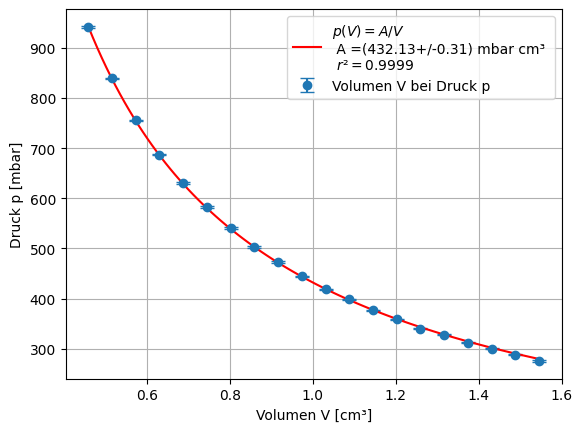

1767+/-18
24.98+/-0.26


In [25]:
# 1.1: Boyle-Mariotte

#Raumkonstanten:
T0 = ufloat(21+273.15, 3)           #Raumtemperatur [K] umrechnen!
p_0 = ufloat(979, 1)               #Luftdruck [mbar]
h_Hg = ufloat(1.3, 0.1)/10          #Größe Quecksilbertropfen [dm] (in cm messen und eingeben)

g = 9.81                            #Erdbeschleunigung [m/s²]
rho_Hg = 13.6                       #Dichte Quecksilber [10³kg/m³]

d = 0.27                            #Durchmesser Kapillare, [cm]
Q = np.pi * d**2 / 4                #Querschnitte, [cm²]

#Messung Druck und Höhe:
delta_p = p_0 - unp.uarray([258, 271, 283, 295, 311, 323, 341, 359, 381, 401, 427, 456, 486, 523, 565, 613, 670, 738, 822, 925], 1)         #gemessene Unterdruck Werte am Manometer, [mbar]
h = unp.uarray([27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8], 0.1)                #Höhe des Quecksilbertropfens (unteres Ende), [cm]; max 25-30 cm!!

#Berechnung p und V:
p_Hg = rho_Hg * g * h_Hg            #Druck des Quecksilbertropfens [mbar]
p = p_0 - delta_p + p_Hg            #Gesamtdruck [mbar]

V = h * Q                           #eingeschlossenes Luftvolumen, [cm³]


#Fit:
V_nom = unp.nominal_values(V)
p_nom = unp.nominal_values(p)
p_std = unp.std_devs(p)

def model_p(V, A):                  #funktion nach der gefittet wird
    return A/V

popt, pcov = curve_fit(model_p, V_nom, p_nom, sigma=p_std, absolute_sigma=True)

A = popt[0]
A_err = np.sqrt(np.diag(pcov))[0]
Au = ufloat(A, A_err)

V_model = np.linspace(min(V_nom), max(V_nom), 100)

ss_res = np.sum((p_nom - model_p(V_nom, A))**2)
ss_tot = np.sum((p_nom - np.mean(p_nom))**2)
r2 = 1 - ss_res/ss_tot


#Plot:
t_control = p_nom * V_nom

plt.figure()
plt.errorbar(V_nom, p_nom, yerr=p_std, fmt='o', capsize=5, label="Volumen V bei Druck p")       #evtl ohne fehlerbalken plotten weil mini?
plt.plot(V_model, model_p(V_model, *popt), '-r', label=f"$p(V) = A/V$ \n A =({Au:.2f}) mbar cm³ \n $r² = {r2:.4f}$")
#plt.plot(V_nom, t_control, '-', color= "orange", label="Kontrollinie $p \cdot V$")
plt.xlabel("Volumen V [cm³]")
plt.ylabel("Druck p [mbar]")
plt.legend()
plt.grid(True)
plt.show()


#Berechnung n:
R = 8.3143                      #Gaskonstante [J/Kmol]

n = (Au/(R * T0)) * 10**4       #molzahl n [mol]
print(n)


#Berechnung molares Volumen:
V0 = ((n * R * T0)/p_0) * 10           #[l = dm³]
V_m = V0/n                      

print(V_m)

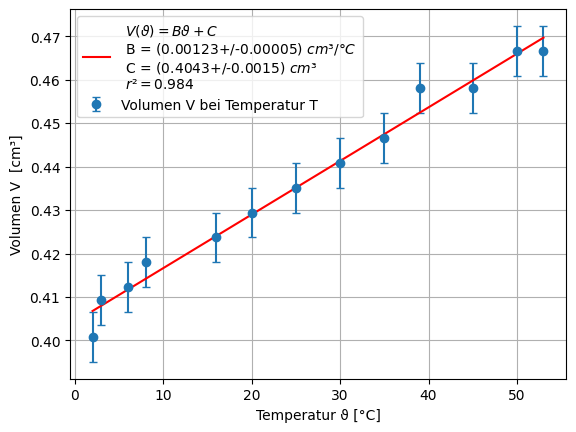

0.00305+/-0.00012
0.0036609921288669233


In [26]:
# 1.2: Gay-Lussac

#Raumkonstanten
T0 = ufloat(21, 3)                  #Raumtemperatur [°C]
p0 = ufloat(979, 1)                #Luftdruck [mbar]

d = 0.27                            #Durchmesser Kapillare, [cm]
Q = np.pi * d**2 / 4                #Querschnitte, [cm²]

alpha_e = 1/273.15                  #erwartetes alpha, [K^-1]

#Messung:
T = unp.uarray([53, 50, 45, 39, 35, 30, 25, 20, 16, 8, 6, 3, 2], 1)                #Temperatur [°C]; Bereich 0-50 °C !!
h = unp.uarray([8.15, 8.15, 8, 8, 7.8, 7.7, 7.6, 7.5, 7.4, 7.3, 7.2, 7.15, 7], 0.1)                #Höhe [cm]

#Berechnung Volumen:
V = h * Q

#Nominalwerte und Fehler:
T_nom = unp.nominal_values(T)
V_nom = unp.nominal_values(V)
V_std = unp.std_devs(V)


#Fit:
res = linregress(T_nom, V_nom)
slope_err = res.stderr
intercept_err = res.intercept_stderr

B = ufloat(res.slope, slope_err)
C = ufloat(res.intercept, intercept_err)

alpha = B/C

#Plot:
plt.figure()
plt.errorbar(T_nom, V_nom, yerr=V_std, fmt='o', capsize=3, label="Volumen V bei Temperatur T")
plt.plot(T_nom, res.slope*T_nom + res.intercept, '-r', label=f" $V(ϑ) = Bϑ + C$ \n B = ({B:.5f}) $cm³/°C$ \n C = ({C:.4f}) $cm³$ \n $r² = {res.rvalue**2:.3f}$")
plt.xlabel("Temperatur ϑ [°C]")
plt.ylabel("Volumen V  [cm³]")
plt.legend()
plt.grid(True)
plt.show()

print(alpha)
print(alpha_e)

In [27]:
# 2. Adiabatenexponent

#Konstanten
m = ufloat(17.2745, 0.0001) * 10**(-3)                 #Masse Kugel [kg]
p0 = ufloat(979, 1) * 10**2                    #äußerer Luftdruck [kg/ms²]
V0 = 0.01                             #Volumen Gefäß [m³]
r = 8 * 10**(-3)                    #Radius Gefäß [m]
g = 9.81                            #[m/s²]

q = np.pi * r**2                    #Querschnitt [m²]

p = unp.nominal_values(p0 + ((m * g) / q))          #Druck [mbar]; (ohne Unsicherheit - steht so in der Anleitung)


#Messung 8Schwingungsdauer
T = unp.uarray([5.42, 5.36, 5.37, 5.4, 5.4, 5.42, 5.29, 5.46, 5.4, 5.17, 5.36, 5.37, 5.26, 5.21, 5.31], 0.01 )/5              #15 Messungen mit jeweils 5 Schwingungen [s]

T_mean = np.mean(T)                 #Mittelwert über Messreihe von 15 Schwingungen [s]
print(T_mean)

#Berechnung Adiabatenexponent
kappa = (((2 * np.pi) / T_mean)**2) * ((m * V0) / (q**2 * p))        

print(kappa)

#Vergleich mit erwartung:
f = 5                               #Freiheitsgrade 2 Atomiges Molekül

kappa_t = (f + 2)/f

print(kappa_t)

1.0693+/-0.0005
1.4941+/-0.0014
1.4


In [29]:
# 3. Dampfdichte

#Konstanten
#m_k = ufloat(7.6525, 0.0003)  
m_k = ufloat(7.8841, 0.0003)              #Masse leerer Kolben [g]
m_kp = ufloat(8.0838, 0.0003)               #Masse Kolben mit Probe [g]; ACHTUNG: ganz kurz vor Messung messen!!
m = m_kp - m_k                  #Masse Probe [g]
print(m)

H = ufloat(738, 1)                  #äußerer Luftdruck [mbar? mmHg?]; evtl umrechen MUSS [mmHg] sein!!

theta = 22                      #Raumtemperatur [°C]; falls nicht diese Werte richtige aus Angabe rausssuchen!!
pw = 19.8                      #zu T korrespondierende Dampfdruckwerte von Wasser [Torr]

h = ufloat(138, 1)                  #Höhe der Wassersäule NACH Versuch [mm]
print(h)

L = ufloat(1.2, 0.1)                  #Luftvolumen im Röhrchen VOR Versuch [cm³]
Vg = ufloat(79, 0.1)                 #Volumen von Luft-Gas-Gemisch NACH Versuch [cm³]
V = Vg - L                      #Gasvolumen in Röhrchen NACH Versuch [cm³]
print(V)

M_L = 28.98                     #molare Masse von Luft [g/mol]


#Rechnung
p = H - (h/13.6) - pw           #Druck [mmHg]

alpha = (m / V) * (760 / p) *((1 + (theta/273.15)) / 0.001293)          #(relative) Dampfdichte, einheitslos

M_S = alpha * M_L               #molare Masse Substanz [g/mol]


print(p)
print(alpha)
print(M_S)

0.1997+/-0.0004
138.0+/-1.0
77.80+/-0.14
708.1+/-1.0
2.302+/-0.007
66.72+/-0.21
